# PCA on Correlation Matrices
In this notebook we apply PCA to the elements of the upper triangle (excluding the diagonal), reconstruct the matrices and measure reconstruction errors (MSE, MAE, Frobenius norm).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)

## Step 1: Load Data
Load the correlation matrices from the .pt file. The file contains:
- `corr_tensor`: tensor of shape (n_windows, n_assets, n_assets)
- Metadata including window ranges, timestamps, and tickers

In [2]:
# Data path configuration
DATA_DIR = Path('../data/processed')
PT_FILE = DATA_DIR / 'corr_windows_tensor_data_00_20_w724_s10.pt'

if not PT_FILE.exists():
    raise FileNotFoundError(f'File not found: {PT_FILE.resolve()}')

PT_FILE

WindowsPath('../data/processed/corr_windows_tensor_data_00_20_w724_s10.pt')

In [3]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta




corr_tensor, meta = load_corr_payload(PT_FILE)

print(f'corr_tensor shape: {tuple(corr_tensor.shape)}')
print(f'dtype: {corr_tensor.dtype}')

corr_tensor shape: (461, 362, 362)
dtype: torch.float32


## Step 2: Extract Upper Triangular Features
Extract only the upper triangle (excluding diagonal) from each correlation matrix.
This reduces dimensionality from n_assets² to n_assets*(n_assets-1)/2 features per sample.

In [4]:
def upper_triangular_features(corr: torch.Tensor):
    corr_np = corr.numpy()
    n_assets = corr_np.shape[1]
    tri_i, tri_j = np.triu_indices(n_assets, k=1)
    X = corr_np[:, tri_i, tri_j]
    return X, tri_i, tri_j, n_assets

X, tri_i, tri_j, n_assets = upper_triangular_features(corr_tensor)
print(f'Number of matrices: {X.shape[0]}')
print(f'Assets per matrix: {n_assets}')
print(f'Upper triangle features: {X.shape[1]}')

Number of matrices: 461
Assets per matrix: 362
Upper triangle features: 65341


## Step 3: Fit PCA Model
Perform PCA via SVD on centered data. Compute:
- Principal components (eigenvectors)
- Variance explained by each component
- Compressed representation (scores)

In [5]:
def fit_pca(X: np.ndarray, n_components: int):
    pca = PCA(n_components=n_components)
    Z = pca.fit_transform(X)
    X_recon = pca.inverse_transform(Z)
    
    return {
        'mean': pca.mean_,
        'components': pca.components_,
        'scores': Z,
        'X_recon': X_recon,
        'explained_ratio_all': pca.explained_variance_ratio_, # Di default riferito a n_components
        'cum_explained_selected': pca.explained_variance_ratio_.sum()
    }



N_COMPONENTS = 20
pca_out = fit_pca(X, n_components=N_COMPONENTS)

var_percent = pca_out["cum_explained_selected"] * 100
print("--- Risultati PCA ---")
print(f"Dimensioni originali:        {X.shape}")
print(f"Dimensioni compresse (Z):    {pca_out['scores'].shape}")
print(f"Componenti estratte:         {N_COMPONENTS}")
print(f"Varianza totale spiegata:    {var_percent:.2f}%\n")
for idx, var in enumerate(pca_out["explained_ratio_all"]):
    print(f"Varianza PC{idx+1}: {(var*100):.2f}%")

--- Risultati PCA ---
Dimensioni originali:        (461, 65341)
Dimensioni compresse (Z):    (461, 20)
Componenti estratte:         20
Varianza totale spiegata:    98.95%

Varianza PC1: 69.19%
Varianza PC2: 11.80%
Varianza PC3: 4.65%
Varianza PC4: 3.61%
Varianza PC5: 2.81%
Varianza PC6: 2.09%
Varianza PC7: 1.27%
Varianza PC8: 0.88%
Varianza PC9: 0.86%
Varianza PC10: 0.45%
Varianza PC11: 0.26%
Varianza PC12: 0.21%
Varianza PC13: 0.16%
Varianza PC14: 0.13%
Varianza PC15: 0.12%
Varianza PC16: 0.11%
Varianza PC17: 0.10%
Varianza PC18: 0.09%
Varianza PC19: 0.08%
Varianza PC20: 0.07%


## Step 4: Reconstruct Correlation Matrices
Rebuild full correlation matrices from the compressed PCA representation.
Set diagonal to 1.0 and enforce symmetry from upper triangle.

In [6]:
def rebuild_corr_matrices_from_upper(X_upper: np.ndarray, tri_i, tri_j, n_assets: int):
    n_samples = X_upper.shape[0]
    mats = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)
    mats[:, tri_i, tri_j] = X_upper
    mats[:, tri_j, tri_i] = X_upper
    mats[:, np.arange(n_assets), np.arange(n_assets)] = 1.0
    return mats





orig_corr = corr_tensor.numpy()
recon_corr = rebuild_corr_matrices_from_upper(pca_out['X_recon'], tri_i, tri_j, n_assets)

print(f'orig_corr shape: {orig_corr.shape}')
print(f'recon_corr shape: {recon_corr.shape}')

orig_corr shape: (461, 362, 362)
recon_corr shape: (461, 362, 362)


## Step 5: Calculate Reconstruction Errors
Measure reconstruction quality using three metrics:
- **MSE**: Mean Squared Error
- **MAE**: Mean Absolute Error  
- **Frobenius**: Frobenius norm of the difference

In [7]:
def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats




errors_df, errors_stats = reconstruction_errors(orig_corr, recon_corr)

print('Reconstruction error statistics:')
display(errors_stats)

print('First 5 rows of errors per matrix:')
display(errors_df.head())

Reconstruction error statistics:


,mean,std,min,median,max
MSE,0.000164,0.000095,0.000056,0.000149,0.001493
MAE,0.009348,0.002178,0.005515,0.009227,0.029504
Frobenius,4.524017,1.001723,2.700911,4.416477,13.989310


First 5 rows of errors per matrix:


,MSE,MAE,Frobenius
0,0.000245,0.012209,5.665809
1,0.000217,0.011405,5.333679
2,0.000161,0.009816,4.598884
3,0.000137,0.009199,4.241149
4,0.000123,0.008659,4.010312


## Step 6: Error Analysis Across Components
Sweep over different numbers of PCA components and track how reconstruction errors decrease as we add more components.

In [11]:
# Error evaluation varying number of components
candidate_components = [2, 3, 5, 10, 20, 30, 50, 80, 100, 200, 362]
candidate_components = [c for c in candidate_components if c <= min(X.shape)]

rows = []
for n_comp in candidate_components:
    out = fit_pca(X, n_comp)
    recon = rebuild_corr_matrices_from_upper(out['X_recon'], tri_i, tri_j, n_assets)
    _, stats = reconstruction_errors(orig_corr, recon)

    rows.append({
        'n_components': n_comp,
        'cumulative_explained_variance': float(out['cum_explained_selected']),
        'MSE_mean': float(stats.loc['MSE', 'mean']),
        'MAE_mean': float(stats.loc['MAE', 'mean']),
        'Frobenius_mean': float(stats.loc['Frobenius', 'mean'])
    })

sweep_df = pd.DataFrame(rows)
display(sweep_df)

,n_components,cumulative_explained_variance,MSE_mean,MAE_mean,Frobenius_mean
0,2,0.809897,2.970068e-03,0.041662,19.349873
1,3,0.856435,2.242980e-03,0.035236,16.452124
2,5,0.920650,1.239729e-03,0.025972,12.318476
3,10,0.976175,3.722258e-04,0.014099,6.789580
4,20,0.989515,1.638228e-04,0.009348,4.524019
5,30,0.993919,9.500911e-05,0.007112,3.424925
6,50,0.996881,4.872925e-05,0.005118,2.464832
7,80,0.998342,2.589634e-05,0.003740,1.801157
8,100,0.998799,1.877264e-05,0.003193,1.536995
9,200,0.999625,5.849006e-06,0.001805,0.860231


## Step 7: Visualize Results
Generate plots showing:
1. **Cumulative explained variance**: How much information is captured as components increase
2. **Reconstruction errors**: MSE, MAE, and Frobenius norm vs. number of components

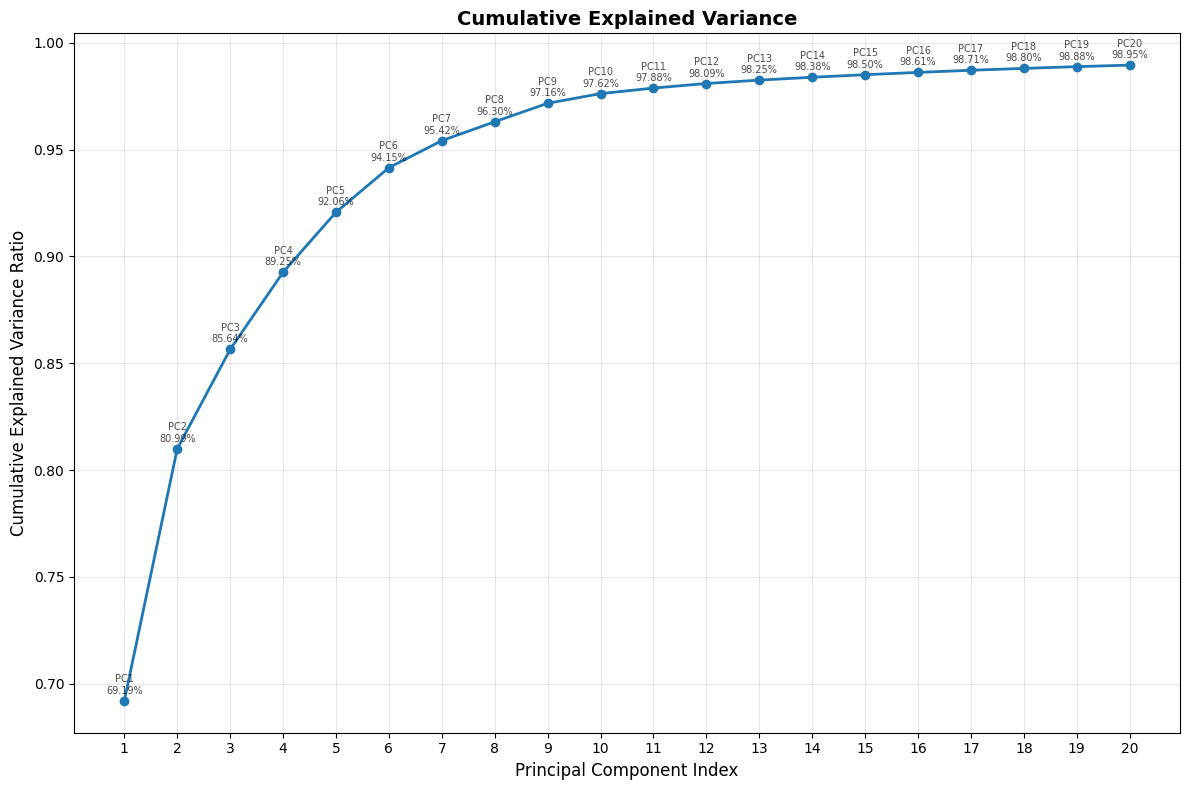

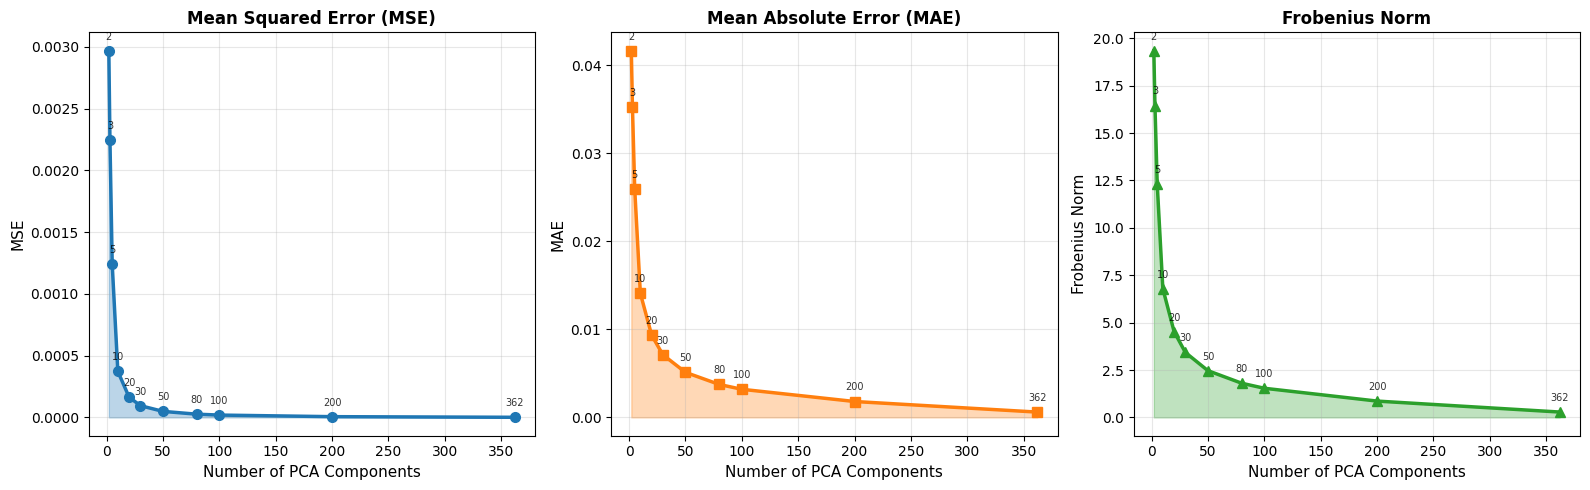

In [12]:
# Plot 1: Cumulative Explained Variance
fig1, ax1 = plt.subplots(figsize=(12, 8))

cum_var = np.cumsum(pca_out['explained_ratio_all'])
ax1.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o', linewidth=2, markersize=6)

# Add annotations with cumulative variance values at each marker
for i, val in enumerate(cum_var):
    ax1.annotate(f'PC{i+1}\n{val*100:.2f}%', 
                 xy=(i+1, val), 
                 xytext=(0, 5), 
                 textcoords='offset points',
                 ha='center',
                 fontsize=7,
                 alpha=0.7)

ax1.set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax1.set_xlabel('Principal Component Index', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax1.set_xticks((np.arange(1, len(cum_var) + 1)))
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Reconstruction Errors with separate subplots for each metric
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))

# MSE subplot
axes[0].plot(sweep_df['n_components'], sweep_df['MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes[0].fill_between(sweep_df['n_components'], sweep_df['MSE_mean'], alpha=0.3, color='#1f77b4')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MSE_mean'])):
    axes[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', 
                     ha='center', fontsize=7, alpha=0.8)
axes[0].set_title('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of PCA Components', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE subplot
axes[1].plot(sweep_df['n_components'], sweep_df['MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes[1].fill_between(sweep_df['n_components'], sweep_df['MAE_mean'], alpha=0.3, color='#ff7f0e')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MAE_mean'])):
    axes[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', 
                     ha='center', fontsize=7, alpha=0.8)
axes[1].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of PCA Components', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Frobenius norm subplot
axes[2].plot(sweep_df['n_components'], sweep_df['Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes[2].fill_between(sweep_df['n_components'], sweep_df['Frobenius_mean'], alpha=0.3, color='#2ca02c')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['Frobenius_mean'])):
    axes[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', 
                     ha='center', fontsize=7, alpha=0.8)
axes[2].set_title('Frobenius Norm', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of PCA Components', fontsize=11)
axes[2].set_ylabel('Frobenius Norm', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()